# K Nearest Neighbors - Projeto

**Grupo 7:**

André Luiz Queiroz Valpassos

Luis Ernani Viniski

Lucas Barbosa dos Santos

Gabriel Bezerra Carrazzoni

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Obtendo os dados

In [ ]:
df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv", sep=";")

# Análise descritiva dos dados

In [ ]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [ ]:
df.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


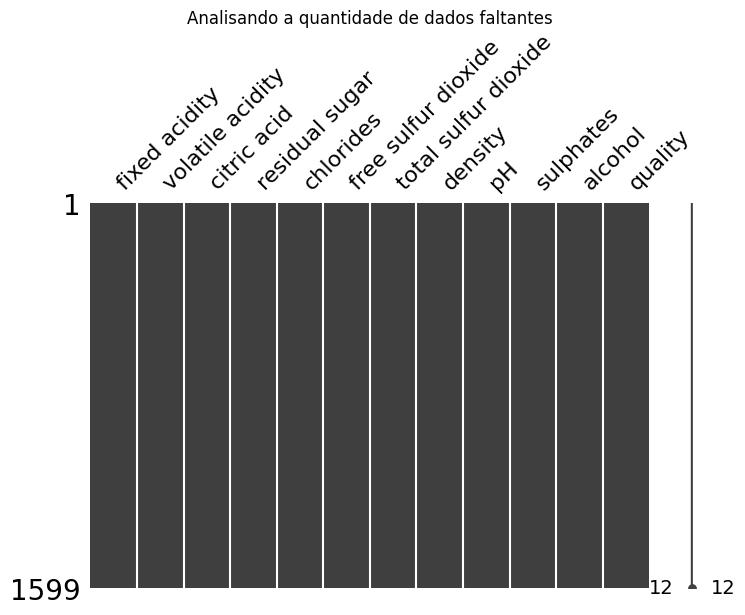

In [ ]:
import missingno as msno
msno.matrix(df, figsize=(8,5))
plt.title("Analisando a quantidade de dados faltantes")
plt.show()

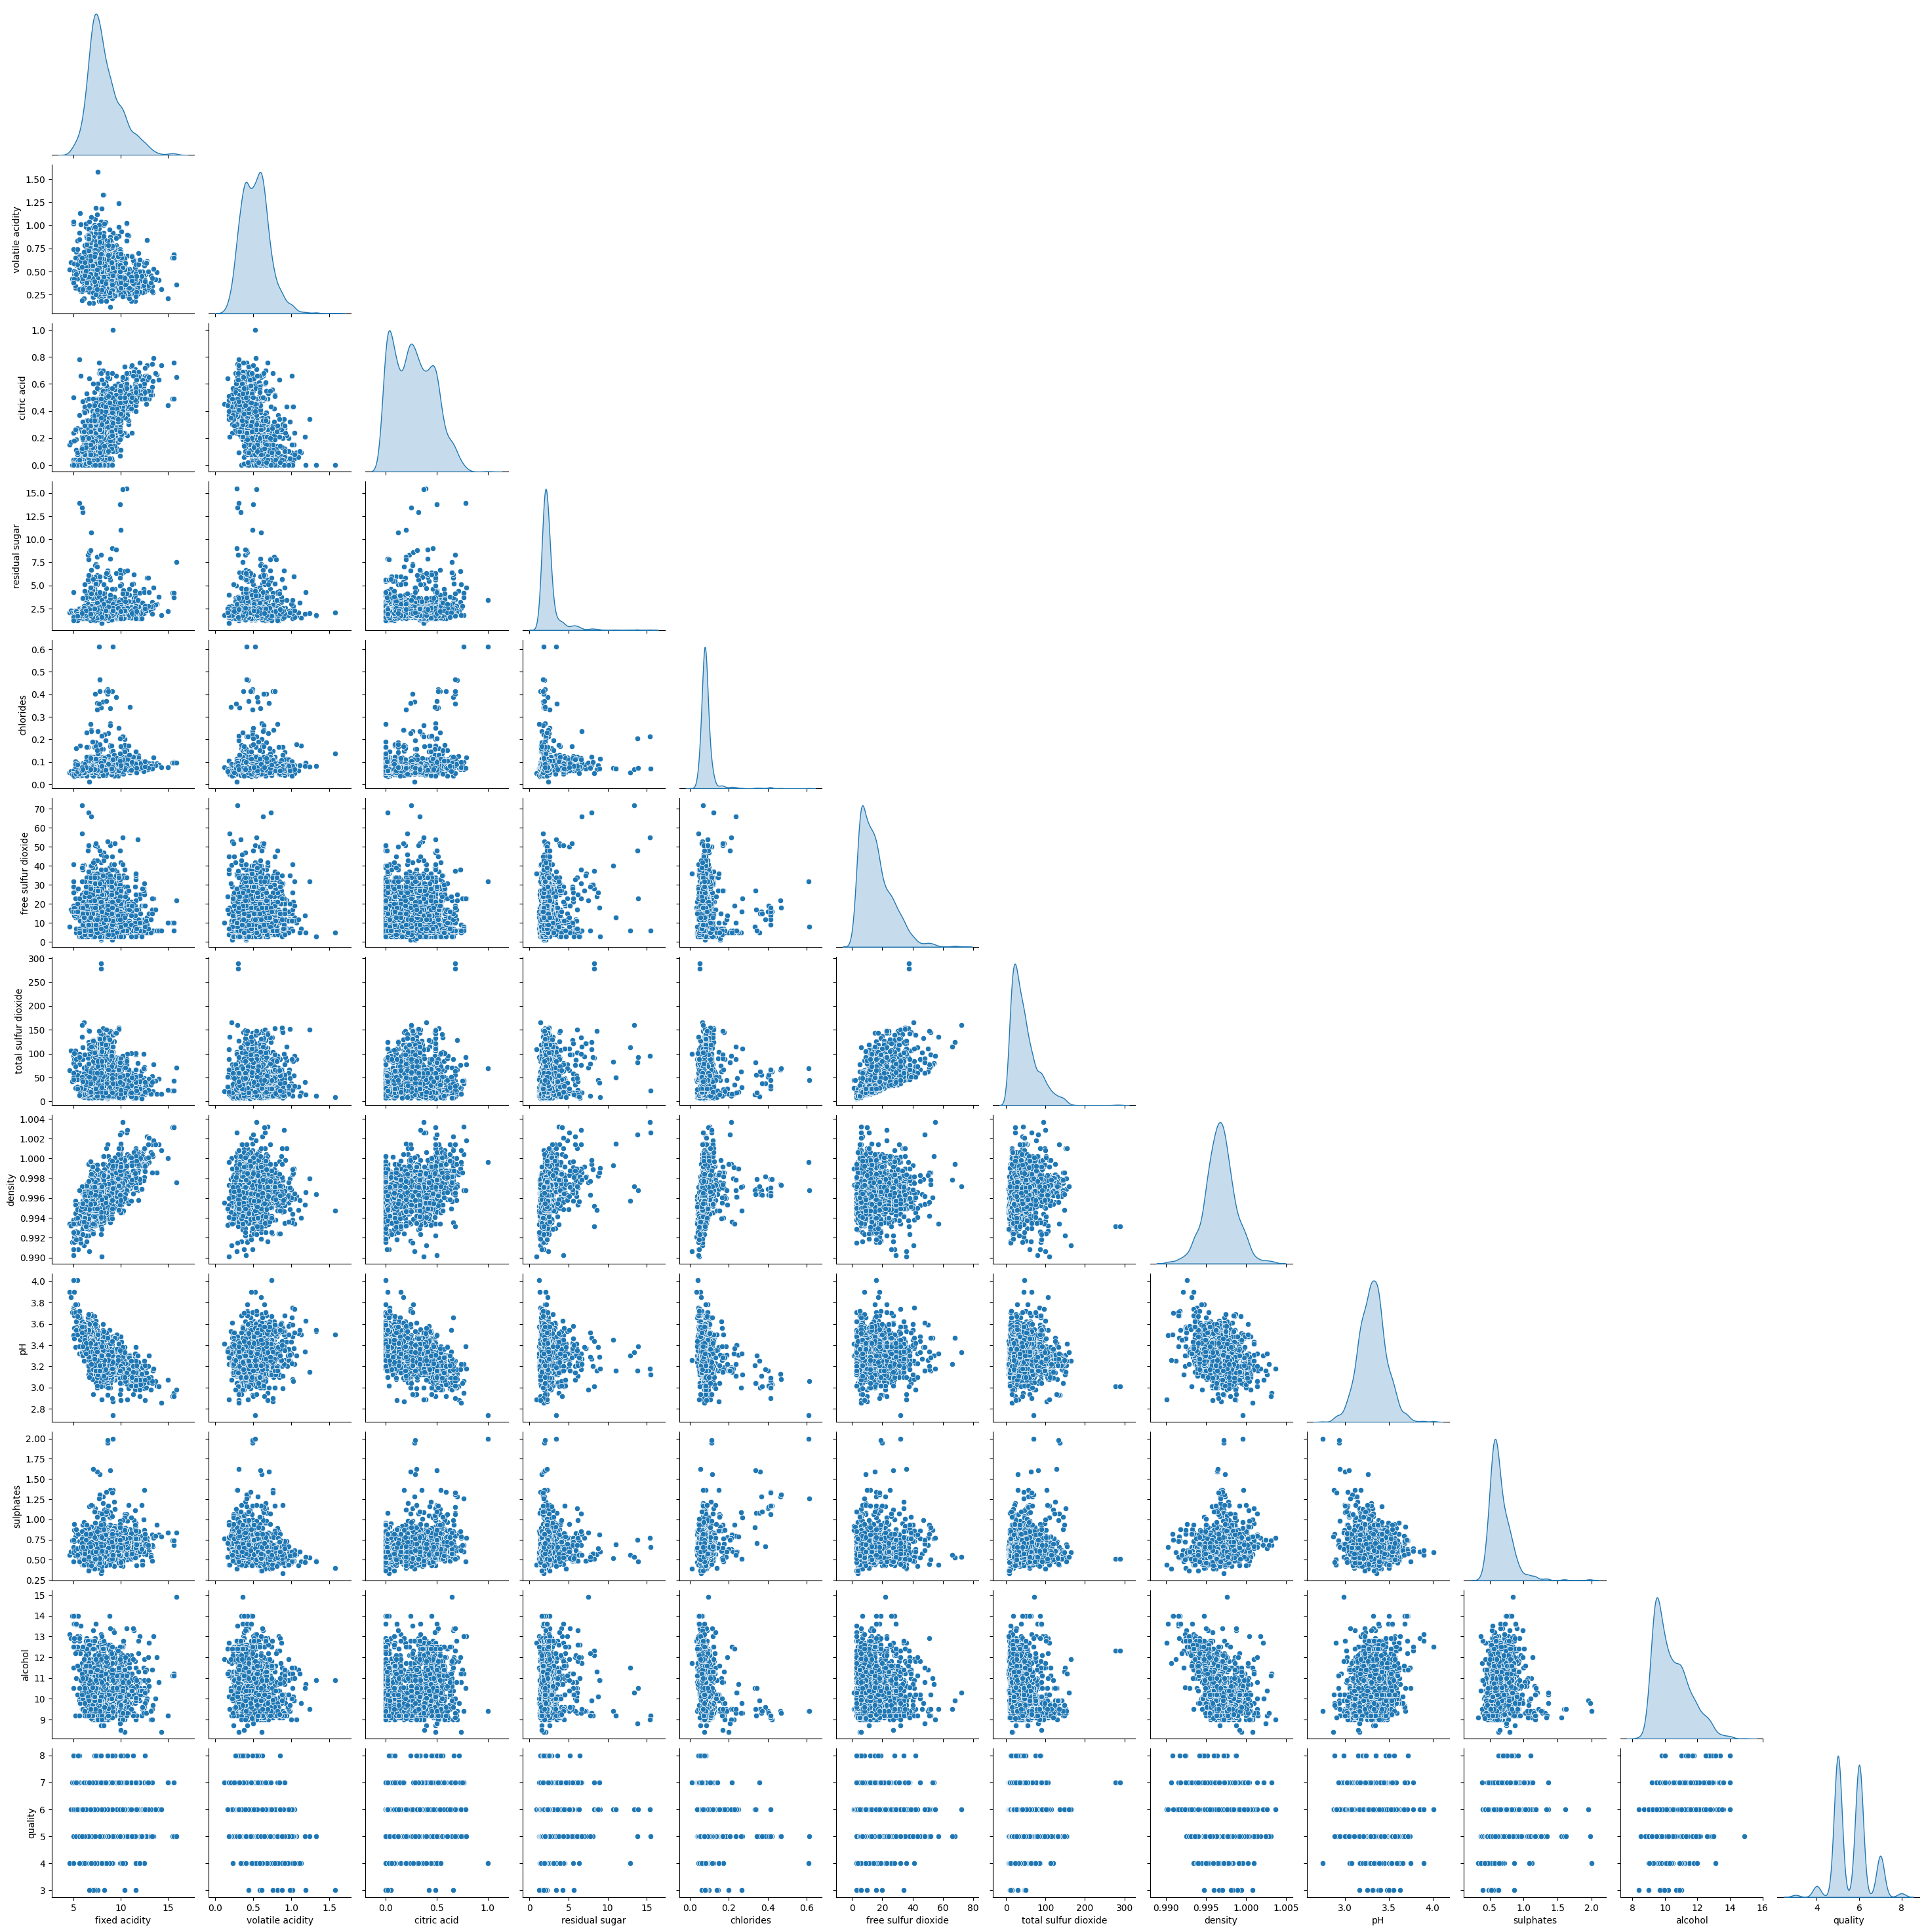

In [ ]:
sns.pairplot(df,corner=True,diag_kind="kde")

<ipython-input-18-f9e533ec2085>:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.hist(ax = ax, grid=False)


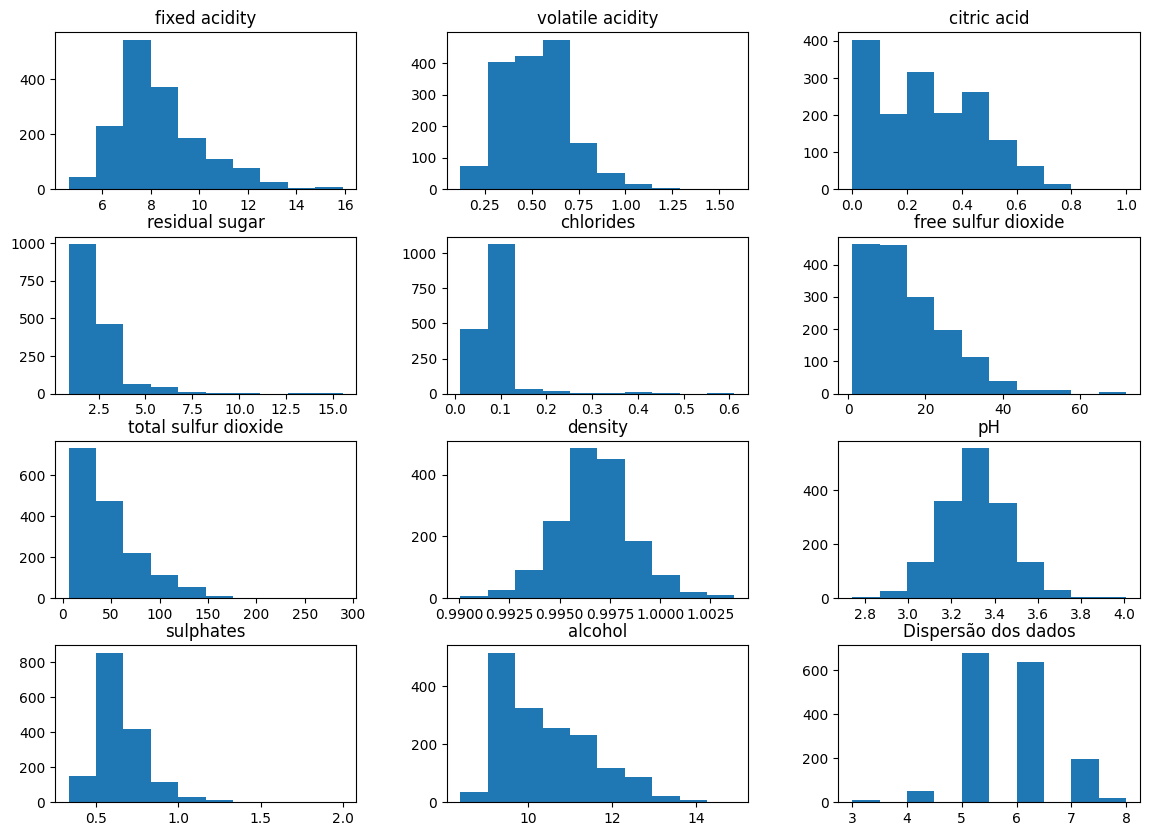

In [ ]:
fig = plt.figure(figsize = (14,10))
ax = fig.gca()
df.hist(ax = ax, grid=False)
plt.title("Dispersão dos dados")
plt.show()

<Axes: >

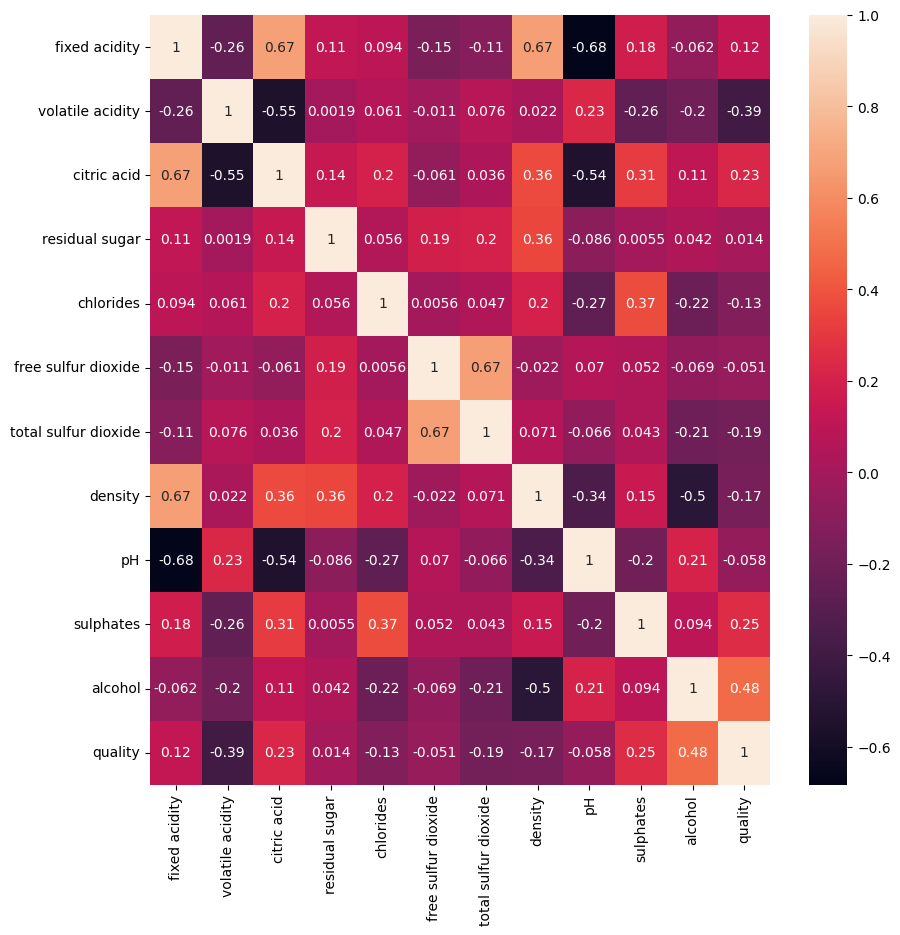

In [ ]:
plt.figure(figsize = (10, 10))
sns.heatmap(df.corr(),annot=True)

# Divisão treino-teste

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['quality']),
                                                    df['quality'],
                                                    test_size=0.25,
                                                    random_state=111)

In [ ]:
X_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
169,7.5,0.705,0.24,1.8,0.360,15.0,63.0,0.99640,3.00,1.59,9.5
1219,9.0,0.390,0.40,1.3,0.044,25.0,50.0,0.99478,3.20,0.83,10.9
1158,6.7,0.410,0.43,2.8,0.076,22.0,54.0,0.99572,3.42,1.16,10.6
976,7.2,0.410,0.30,2.1,0.083,35.0,72.0,0.99700,3.44,0.52,9.4
654,8.6,0.470,0.47,2.4,0.074,7.0,29.0,0.99790,3.08,0.46,9.5
...,...,...,...,...,...,...,...,...,...,...,...
681,8.0,0.450,0.23,2.2,0.094,16.0,29.0,0.99620,3.21,0.49,10.2
1299,7.6,1.580,0.00,2.1,0.137,5.0,9.0,0.99476,3.50,0.40,10.9
86,8.6,0.490,0.28,1.9,0.110,20.0,136.0,0.99720,2.93,1.95,9.9
724,7.5,1.115,0.10,3.1,0.086,5.0,12.0,0.99580,3.54,0.60,11.2


In [ ]:
y_train

,quality
169,5
1219,6
1158,6
976,5
654,5
...,...
681,6
1299,3
86,6
724,4


In [ ]:
X_test

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
660,7.2,0.52,0.07,1.4,0.074,5.0,20.0,0.99730,3.32,0.81,9.6
1351,7.2,0.62,0.01,2.3,0.065,8.0,46.0,0.99332,3.32,0.51,11.8
230,5.2,0.48,0.04,1.6,0.054,19.0,106.0,0.99270,3.54,0.62,12.2
1111,5.4,0.42,0.27,2.0,0.092,23.0,55.0,0.99471,3.78,0.64,12.3
444,5.3,0.57,0.01,1.7,0.054,5.0,27.0,0.99340,3.57,0.84,12.5
...,...,...,...,...,...,...,...,...,...,...,...
1345,8.2,0.44,0.24,2.3,0.063,10.0,28.0,0.99613,3.25,0.53,10.2
139,7.8,0.56,0.19,2.0,0.081,17.0,108.0,0.99620,3.32,0.54,9.5
926,9.4,0.24,0.33,2.3,0.061,52.0,73.0,0.99786,3.47,0.90,10.2
929,8.7,0.33,0.38,3.3,0.063,10.0,19.0,0.99468,3.30,0.73,12.0


In [ ]:
y_test

,quality
660,6
1351,6
230,7
1111,7
444,7
...,...
1345,6
139,5
926,6
929,7


# Normalização das variáveis

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
pd.DataFrame(X_train_scaled)

,0,1,2,3,4,5,6,7,8,9,10
0,-0.479762,0.949064,-0.157909,-0.516798,5.520320,-0.081844,0.510394,-0.192426,-2.007669,5.276430,-0.863805
1,0.399802,-0.779267,0.659503,-0.859823,-0.904419,0.873203,0.114922,-1.067771,-0.714486,0.963542,0.448832
2,-0.948862,-0.669532,0.812768,0.169252,-0.253812,0.586689,0.236606,-0.559854,0.708015,2.836243,0.167553
3,-0.655675,-0.669532,0.148620,-0.310983,-0.111492,1.828250,0.784182,0.131776,0.837333,-0.795663,-0.957565
4,0.165251,-0.340326,1.017121,-0.105168,-0.294475,-0.845882,-0.523917,0.618079,-1.490396,-1.136154,-0.863805
...,...,...,...,...,...,...,...,...,...,...,...
1194,-0.186574,-0.450061,-0.208997,-0.242378,0.112154,0.013661,-0.523917,-0.300493,-0.649827,-0.965908,-0.207486
1195,-0.421124,5.749982,-1.384028,-0.310983,0.986406,-1.036891,-1.132336,-1.078577,1.225288,-1.476645,0.448832
1196,0.165251,-0.230591,0.046444,-0.448193,0.437457,0.395679,2.731122,0.239844,-2.460283,7.319377,-0.488766
1197,-0.479762,3.198637,-0.873145,0.375068,-0.050498,-1.036891,-1.041073,-0.516627,1.483924,-0.341674,0.730112


In [ ]:
pd.DataFrame(X_test_scaled)

,0,1,2,3,4,5,6,7,8,9,10
0,-0.655675,-0.065988,-1.026410,-0.791218,-0.294475,-1.036891,-0.797706,0.293877,0.061423,0.850045,-0.770045
1,-0.655675,0.482689,-1.332939,-0.173773,-0.477458,-0.750377,-0.006762,-1.856662,0.061423,-0.852411,1.292671
2,-1.828426,-0.285458,-1.179674,-0.654008,-0.701104,0.300175,1.818494,-2.191670,1.483924,-0.228177,1.667710
3,-1.711151,-0.614664,-0.004644,-0.379588,0.071491,0.682194,0.267027,-1.105594,3.035744,-0.114680,1.761470
4,-1.769788,0.208351,-1.332939,-0.585403,-0.701104,-1.036891,-0.584759,-1.813435,1.677902,1.020290,1.948990
...,...,...,...,...,...,...,...,...,...,...,...
395,-0.069299,-0.504929,-0.157909,-0.173773,-0.518121,-0.559368,-0.554338,-0.338316,-0.391190,-0.738914,-0.207486
396,-0.303849,0.153483,-0.413350,-0.379588,-0.152155,0.109165,1.879336,-0.300493,0.061423,-0.682166,-0.863805
397,0.634352,-1.602282,0.301885,-0.173773,-0.558784,3.451830,0.814603,0.596466,1.031310,1.360782,-0.207486
398,0.223889,-1.108473,0.557327,0.512278,-0.518121,-0.559368,-0.828127,-1.121804,-0.067895,0.396056,1.480191


In [ ]:
pd.DataFrame(X_train_scaled).describe()

,0,1,2,3,4,5,6,7,8,9,10
count,1.199000e+03,1.199000e+03,1.199000e+03,1.199000e+03,1.199000e+03,1.199000e+03,1.199000e+03,1.199000e+03,1.199000e+03,1.199000e+03,1.199000e+03
mean,-7.111353e-17,-1.718577e-16,1.659316e-16,-1.333379e-16,-1.155595e-16,2.074145e-17,-8.889192e-17,7.994347e-15,-2.814911e-16,-1.363009e-16,3.022325e-16
std,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00,1.000417e+00
min,-2.180251e+00,-2.260693e+00,-1.384028e+00,-1.134243e+00,-1.555025e+00,-1.418910e+00,-1.223599e+00,-3.612755e+00,-3.688806e+00,-1.873885e+00,-1.895163e+00
25%,-7.143121e-01,-7.381162e-01,-9.242331e-01,-4.481928e-01,-3.554698e-01,-7.981295e-01,-7.368639e-01,-5.814678e-01,-6.498270e-01,-6.254171e-01,-8.638051e-01
50%,-2.452116e-01,-6.598761e-02,-5.573265e-02,-2.423777e-01,-1.724867e-01,-1.773488e-01,-2.501290e-01,2.370901e-02,-3.235653e-03,-2.281774e-01,-2.074863e-01
75%,5.170767e-01,6.061410e-01,8.127678e-01,3.204238e-02,5.115929e-02,4.911842e-01,4.799732e-01,5.775539e-01,5.786965e-01,4.528050e-01,6.363521e-01
max,4.445793e+00,5.749982e+00,3.724799e+00,8.882091e+00,1.062351e+01,5.361925e+00,7.385524e+00,3.746627e+00,4.522904e+00,7.603120e+00,4.199226e+00


In [ ]:
X_train_original = scaler.inverse_transform(X_train_scaled)

In [ ]:
pd.DataFrame(X_train_original).head(5)

,0,1,2,3,4,5,6,7,8,9,10
0,7.5,0.705,0.24,1.8,0.360,15.0,63.0,0.99640,3.00,1.59,9.5
1,9.0,0.390,0.40,1.3,0.044,25.0,50.0,0.99478,3.20,0.83,10.9
2,6.7,0.410,0.43,2.8,0.076,22.0,54.0,0.99572,3.42,1.16,10.6
3,7.2,0.410,0.30,2.1,0.083,35.0,72.0,0.99700,3.44,0.52,9.4
4,8.6,0.470,0.47,2.4,0.074,7.0,29.0,0.99790,3.08,0.46,9.5


In [ ]:
X_train.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
169,7.5,0.705,0.24,1.8,0.360,15.0,63.0,0.99640,3.00,1.59,9.5
1219,9.0,0.390,0.40,1.3,0.044,25.0,50.0,0.99478,3.20,0.83,10.9
1158,6.7,0.410,0.43,2.8,0.076,22.0,54.0,0.99572,3.42,1.16,10.6
976,7.2,0.410,0.30,2.1,0.083,35.0,72.0,0.99700,3.44,0.52,9.4
654,8.6,0.470,0.47,2.4,0.074,7.0,29.0,0.99790,3.08,0.46,9.5


# Usando o KNN com k = 1

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier(n_neighbors=1)

In [ ]:
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=1)

# Previsões e avaliações

In [ ]:
y_pred = knn.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo: {accuracy:.2f}")

Acurácia do modelo: 0.62


<Figure size 1600x1200 with 0 Axes>

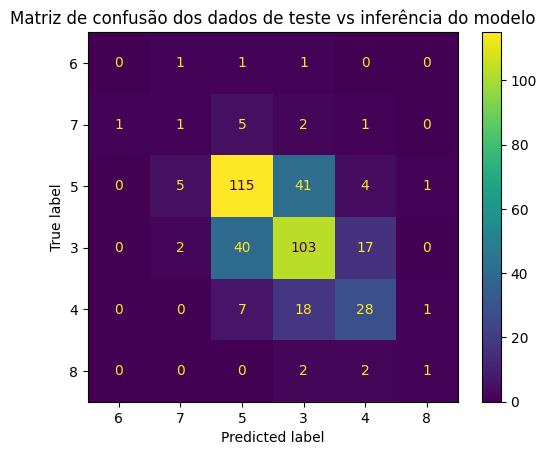

In [ ]:
plt.figure(figsize = (16,12))
cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels=y_test.unique())
cmd.plot()
plt.title("Matriz de confusão dos dados de teste vs inferência do modelo")
plt.show()

In [ ]:
knn.score(X=X_test_scaled, y=y_test)

0.62

## Curva ROC

In [ ]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import RocCurveDisplay

In [ ]:
label_binarizer = LabelBinarizer().fit(df['quality'])

In [ ]:
y_onehot_test = label_binarizer.transform(y_test)
y_onehot_test.shape  # (n_samples, n_classes)

(400, 6)

In [ ]:
class_of_interest = 5
class_id = np.flatnonzero(label_binarizer.classes_ == class_of_interest)[0]
class_id

np.int64(2)

In [ ]:
y_scores = knn.predict_proba(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


In [ ]:
def plot_curva_ROC_one_vs_rest(y_test, y_scores):

  RocCurveDisplay.from_predictions(
      y_onehot_test[:, class_id],
      y_scores[:, class_id],
      name=f"{class_of_interest} vs as demais classes",
  )
  plt.plot([0, 1], [0, 1], "k--", label="valor de threashold (AUC = 0.5)")
  plt.axis("square")
  plt.xlabel("Taxa de Falso Positivo")
  plt.ylabel("Taxa de Verdadeira Positivo")
  plt.title("One-vs-Resto curva ROC")
  plt.legend()
  plt.show()

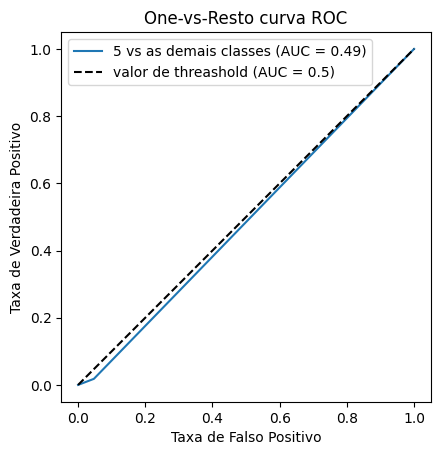

In [ ]:
plot_curva_ROC_one_vs_rest(y_test, y_scores)

# Escolhendo o valor K com o método do cotovelo

In [ ]:
def train_modelo(X_train_scaled, X_test_scaled, y_train, k=1):
    print(f"Treinando o k-NN com k={k}")

    # Criar e treinar o modelo
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    # Fazer predições nos dados de teste
    pred_i = knn.predict(X_test_scaled)

    return pred_i  # Agora, pred_i está definido corretamente

# Lista para armazenar as taxas de erro
error_rate = []

for i in range(1, 41):
    pred_i = train_modelo(X_train_scaled, X_test_scaled, y_train, i)

    # Calcular taxa de erro e armazenar
    error = (pred_i != y_test).mean()  # y_test deve estar definido anteriormente
    error_rate.append(error)


Treinando o k-NN com k=1
Treinando o k-NN com k=2
Treinando o k-NN com k=3
Treinando o k-NN com k=4
Treinando o k-NN com k=5
Treinando o k-NN com k=6
Treinando o k-NN com k=7
Treinando o k-NN com k=8
Treinando o k-NN com k=9
Treinando o k-NN com k=10
Treinando o k-NN com k=11
Treinando o k-NN com k=12
Treinando o k-NN com k=13
Treinando o k-NN com k=14
Treinando o k-NN com k=15
Treinando o k-NN com k=16
Treinando o k-NN com k=17
Treinando o k-NN com k=18
Treinando o k-NN com k=19
Treinando o k-NN com k=20
Treinando o k-NN com k=21
Treinando o k-NN com k=22
Treinando o k-NN com k=23
Treinando o k-NN com k=24
Treinando o k-NN com k=25
Treinando o k-NN com k=26
Treinando o k-NN com k=27
Treinando o k-NN com k=28
Treinando o k-NN com k=29
Treinando o k-NN com k=30
Treinando o k-NN com k=31
Treinando o k-NN com k=32
Treinando o k-NN com k=33
Treinando o k-NN com k=34
Treinando o k-NN com k=35
Treinando o k-NN com k=36
Treinando o k-NN com k=37
Treinando o k-NN com k=38
Treinando o k-NN com 

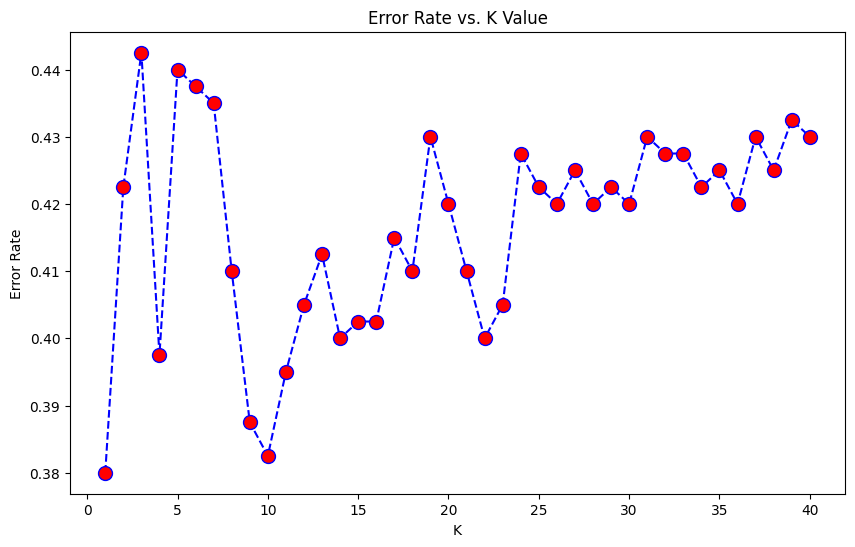

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(range(1,41),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

In [ ]:
# Lista para armazenar os scores
res_score = []

# Loop de 1 a 40 para treinar o modelo com diferentes valores de k
for i in range(1, 41):
    pred_i = train_modelo(X_train_scaled, X_test_scaled, y_train, i)

    # Calcular e armazenar o score (acurácia)
    score = accuracy_score(y_test, pred_i)  # y_test deve estar definido
    res_score.append(score)


Treinando o k-NN com k=1
Treinando o k-NN com k=2
Treinando o k-NN com k=3
Treinando o k-NN com k=4
Treinando o k-NN com k=5
Treinando o k-NN com k=6
Treinando o k-NN com k=7
Treinando o k-NN com k=8
Treinando o k-NN com k=9
Treinando o k-NN com k=10
Treinando o k-NN com k=11
Treinando o k-NN com k=12
Treinando o k-NN com k=13
Treinando o k-NN com k=14
Treinando o k-NN com k=15
Treinando o k-NN com k=16
Treinando o k-NN com k=17
Treinando o k-NN com k=18
Treinando o k-NN com k=19
Treinando o k-NN com k=20
Treinando o k-NN com k=21
Treinando o k-NN com k=22
Treinando o k-NN com k=23
Treinando o k-NN com k=24
Treinando o k-NN com k=25
Treinando o k-NN com k=26
Treinando o k-NN com k=27
Treinando o k-NN com k=28
Treinando o k-NN com k=29
Treinando o k-NN com k=30
Treinando o k-NN com k=31
Treinando o k-NN com k=32
Treinando o k-NN com k=33
Treinando o k-NN com k=34
Treinando o k-NN com k=35
Treinando o k-NN com k=36
Treinando o k-NN com k=37
Treinando o k-NN com k=38
Treinando o k-NN com 

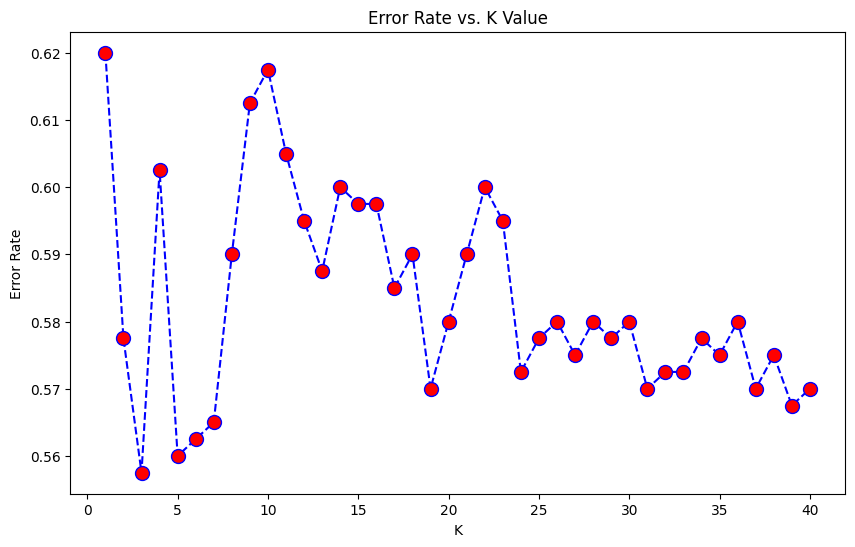

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(range(1,41),res_score,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

## Treinando novamente o modelo com valor de K = 3

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)

In [ ]:
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_pred = knn.predict(X_test_scaled)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo: {accuracy:.2f}")

Acurácia do modelo: 0.56


<Figure size 1600x1200 with 0 Axes>

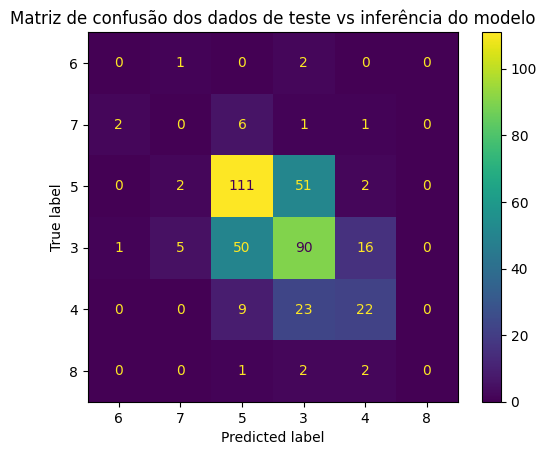

In [ ]:
plt.figure(figsize = (16,12))
cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels=y_test.unique())
cmd.plot()
plt.title("Matriz de confusão dos dados de teste vs inferência do modelo")
plt.show()

In [ ]:
y_scores = knn.predict_proba(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


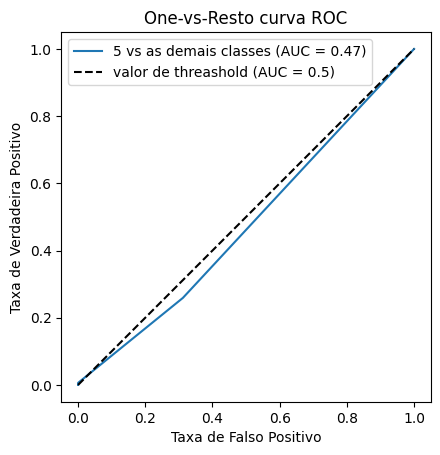

In [ ]:
plot_curva_ROC_one_vs_rest(y_test, y_scores)

## Treinando novamente o modelo com novo valor de K = 11

In [ ]:
knn = KNeighborsClassifier(n_neighbors=11)

In [ ]:
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=11)

In [ ]:
y_pred = knn.predict(X_test_scaled)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo: {accuracy:.2f}")

Acurácia do modelo: 0.60


<Figure size 1600x1200 with 0 Axes>

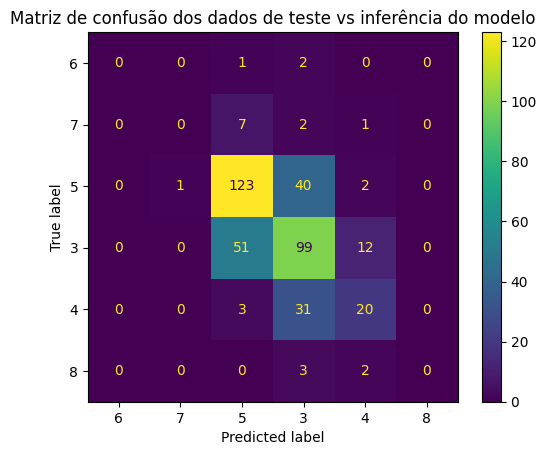

In [ ]:
plt.figure(figsize = (16,12))
cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels=y_test.unique())
cmd.plot()
plt.title("Matriz de confusão dos dados de teste vs inferência do modelo")
plt.show()

In [ ]:
y_scores = knn.predict_proba(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


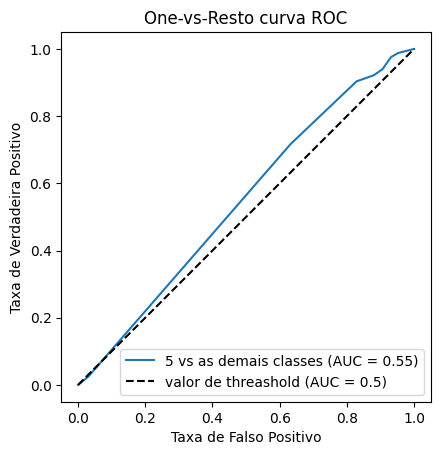

In [ ]:
plot_curva_ROC_one_vs_rest(y_test, y_scores)

##**Conclusão**

**1. Análise Exploratória dos Dados:**

*   Inspeção inicial: Uso dos métodos .info() e .describe() para entender o formato dos dados e suas estatísticas básicas.

*   Tratamento de dados faltantes: Nenhum dado ausente foi encontrado.

*   Visualização dos dados:

1.   Gráficos de dispersão para analisar relações entre as variáveis.

2.   Distribuições das variáveis para entender sua forma e possíveis outliers.

3.   Matriz de correlação para verificar relações lineares entre os atributos e a variável alvo (quality).


**2. Preparação dos Dados:**

*   Divisão em treino e teste: Utilizando a estratégia hold-out, os dados foram separados em conjuntos de treino e teste.

*   Normalização: Aplicação do StandardScaler para padronizar os dados, garantindo que todas as variáveis tenham média 0 e desvio padrão 1.

**3. Treinamento e Avaliação do Modelo:**
  1.   **KNN com k = 1:**
    *   Matriz de confusão gerada.
    *   score de 0,62.
    *   Curva ROC construída com abordagem "um contra todos" (one vs all).

**Escolha do Melhor k (Método do Cotovelo):**

*   O método indicou que k = 1 tinha o menor erro e o melhor score.

**Testes com outros valores de k:**

  **k = 3:**

    1.   Maior erro e menor score (0,56).

    2.   Pior curva ROC.


  **k = 11:**

    1.   Segundo menor erro e segundo maior score (0,60).

    2.   Melhor curva ROC entre os três valores testados.

**Conclusão sobre Melhor Valor de k:**

O método do cotovelo indicou que k = 1 era o melhor valor, pois apresentou o menor erro e o maior score geral (0,62).

No entanto, a melhor curva ROC foi observada para k = 11, sugerindo que, para alguns critérios, ele poderia ser um candidato melhor dependendo do contexto de uso do modelo.

A escolha final de k = 1 faz sentido para maximizar a acurácia global, embora k = 11 tenha mostrado uma ROC superior, o que pode indicar uma melhor separabilidade entre as classes.